# [HW06] Realistic Pendulum 1


Analytical solutions usually work only in certain limits/approximations. When these fail, numerical methods step in to solve differential equations.

In numerical integration, we start at $t=0$ and iteratively estimate $f(t+dt)$, $f'(t+dt)$, $f''(t+dt)$, $\dots$

The process continues until we generate a complete set of values for the function and its first derivative.

In this homework, we examine the numerical solution for a realistic pendulum.

🎯 **Assignment:**

We will use the ODE solver to determine $\theta (t)$ for a realistic pendulum through the following sections:

* **(Appendix):** First, review the numerical integration technique from * Bead on Cone* (included in Appendix)
* **(Step 1):** Equations of motion and setup for realistic pendulum
* **Step 2):** Construct a similar numerical integration code for the realistic pendulum.
* (**Step 3**) Sensemaking: Choose a theta_initial which should fit within the small angle approximation - what period do you measure ?  Look at your plot - does it make sense? Discuss in writing what you observe. If it does not make sense or looks incorrect, fix it.
*  (**Step 4**) Choose a theta_initial which would not fit the small angle approximation- how is it different? does it still make sense? Discuss what you did and confirm.

<!--
Note: While you may use the Gemini spark icon in Google Colab for debugging assistance, rely primarily on class resources rather than having AI generate the entire solution. -->

## Step 1: Equations of motion (theory)

**Equations of motion (EOM):**

1. $\frac{d \theta}{dt}=\omega$
2. $\frac{d^{2}\theta}{dt^{2}}= - \frac{g}{L}\sin\theta$  

**Variables:**

* $\theta$: angle of the pendulum with the vertical
* $\omega = \frac{d\theta}{dt}$: angular speed of the pendulum

---

Our numerical solver `solve_ivp` (a `SciPy` function) requires a system of first-order ordinary differential equations (ODEs), so we convert the second-order equation into two first-order equations.
* input to solve_ivp:
  * position= theta (from which it calculates an approximate velocity at a time *dt* later)
  * velocity= theta' (from which it calculates an approximate acceleration at a time *dt* later)
  * array of time points
* solve_ivp will then output
  * a list of values for the function f(t) (theta, and theta' in this case)

To solve a 2nd order differential equation we need to create a matrix of equations a "state vector". This is because we can only have ONE input function.

Let us define the state vector $ \mathbf{U}(t) = \left(\begin{array}{c} \theta(t) \\ \omega(t) \end{array}\right) $.

Taking a derivative and making some replacements, we obtain the revised EOM:

$$ \frac{d\mathbf{U}}{dt} = \left(\begin{array}{c} \theta'(t) \\ \omega'(t) \end{array}\right) = \left(\begin{array}{c} \omega(t) \\ -\frac{g}{L}\sin\theta \end{array}\right),$$

with initial conditions $ \mathbf{U}(0) = \left(\begin{array}{c} \theta_0 \\ \omega_0 \end{array}\right) $.

## Step 2: Numerical integration for the realistic pendulum

👉 Fill in the missing code wherever you see `'''Write code here'''`

#### A0 Import libraries

In [ ]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.integrate import odeint
from scipy.signal import find_peaks

#### A1 Write your dU/dt derivative function

In [ ]:
# Create derivative function
  # Inputs:
  #   'time': current time point
  #   'U': array w/ theta = U[0] and omega = U[1]
  # Output:
  #   dU_dt = [theta', omega'] (use the equations derived above)
  #   The function requires the current time point as an input during numerical integration.

def dU_dt_pendulum(time,U):
  '''Write code here'''
  # Ensure you preserve indentation


#### A2 define variables

Step 3: Choose a theta_initial which should fit within the small angle approximation - what period do you measure ?

In [ ]:
# Definitions
##        variables you need to define are:
##        time array
##        g
##        L
##        omega_initial = (set to zero)
##        theta_initial
##        U_initial values

# Time array and increment (dt)
'''Write code here'''

g = 9.8
L = 1.0  # Length of pendulum

# omega initial, and theta_initial and U_initial
'''Write code here'''


#### A3 Calculate the derivatives using dU_dt function above


In [ ]:
''' type your code here '''

### A4: Plot theta(t)


In [ ]:
''' type your code here '''

## Step 3: Look at your plot - does it make sense?
Things to check: vary theta_initial, does it still make sense?

*Double click here to write your answer. Include what values of theta_initial you chose.*

## Step 4:  Choose a theta_initial which would not fit the small angle approximation.
How is it different?
does it still make sense? Discuss what you did and confirm.

*Double click here to write your answer. Include what values of theta_initial you chose.*

## Appendix: Code for *Bead on cone*

Under the influence of gravity, a bead rolls down and around the surface of a cone.

**Variables:**
* $r$: Radial distance of the bead from the central axis
* $\theta$: Angular position in cylindrical coordinates
* $\omega$: Angular velocity of the bead
* $\alpha$: Angle of the cone relative to the vertical axis
* $g$: Acceleration due to gravity

**Equations of motion (EOM):**

1. Angular Momentum: $\frac{dl}{dt} = 0 $, where $l = m r^{2}\omega = m R_{0}^{2}\omega_{0}$ is a constant

2. Radial Motion: $\frac{d^{2}r}{dt^{2}} - r\omega^2\sin^{2}\alpha + g\sin\alpha \cos\alpha = 0$

Since our numerical solver `solve_ivp` (a `SciPy` function) requires a system of first-order ordinary differential equations (ODEs), we can convert the second-order radial equation into two first-order equations.

Let us define the state vector $ \mathbf{U}(t) = \left(\begin{array}{c} r(t) \\ v(t) \end{array}\right) $.

Taking a derivative and making some replacements, we obtain:

$$ \frac{d\mathbf{U}}{dt} = \left(\begin{array}{c} r'(t) \\ v'(t) \end{array}\right) = \left(\begin{array}{c} v(t) \\ \frac{(R_{0}^{2}w_{0})^2}{r^3}\sin^{2}\alpha - g\sin\alpha \cos\alpha \end{array}\right),$$

with initial conditions $ \mathbf{U}(0) = \left(\begin{array}{c} R_0 \\ v_0 \end{array}\right) $.

So the revised EOM:
1. $\frac{d \theta}{dt}= \omega = \frac{R_{0}^{2}w_{0}}{r^{2}}$
2. $\frac{dr}{dt} = v$
3. $\frac{dv}{dt}=\frac{(R_{0}^{2}w_{0})^2}{r^3}\sin^{2}\alpha - g\sin\alpha \cos\alpha $

Once we solve for $r(t)$ and $v(t)$ using `solve_ivp`, we can subsequently compute the angular trajectory $\theta(t)$ using EOM (1).

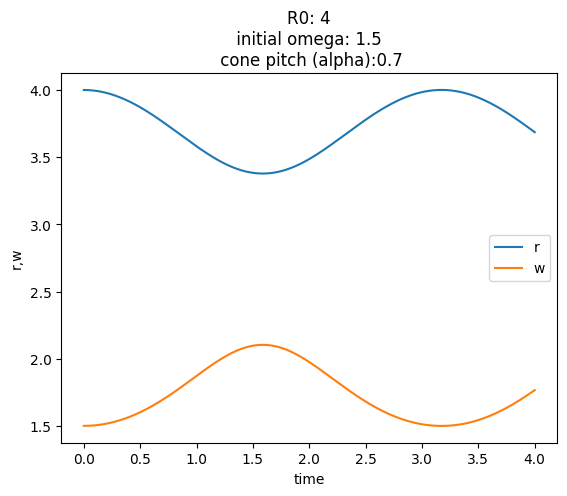

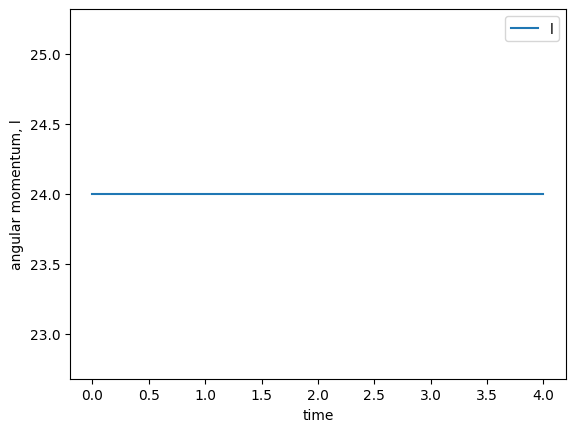

In [ ]:
# (0) Import libraries
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# (i) Derivative function
  # Inputs:
  #   'time': current time point
  #   'U': array w/ r = U[0] and v = U[1]
  # Output
  #   dU_dt = [r',v'] = [v,a]
  #   The function requires the current time point as an input during numerical integration.

def dU_dt(time, U):
  # Current velocity and acceleration
  r_prime=U[1]
  v_prime=((R0*R0*w0)**2/(U[0]**3)*np.sin(alpha)*np.sin(alpha)-g*np.sin(alpha)*np.cos(alpha))

  return [r_prime, v_prime]

# (ii) Definitions

# Constants and initial conditions
R0 = 4 # Initial radius
v0 = 0 # Initial radial velocity
w0 = 1.5 # Initial angular velocity in rad/s
alpha = 0.7 # Angle of cone w.r.t. vertical
g = 9.8
t_final = 4

# Time array and increment
time = np.linspace(0, t_final, 1000)  # Set up the array of time
dt=time[1]-time[0]

# State vector
U_0 = [R0, v0] # Initialize your U_0 matrix !  U_0 = [r(0)=R0, v(0)=v0]

# (iii) Numerical integration
U_pts = solve_ivp(dU_dt, (time[0],time[-1]),U_0, t_eval = time)

# (iv) Extract r(t)
r = U_pts.y[0,:]

# (v) Physicality
# Filter r and time to include only r > 0 values (keeping values in cone)
r_gt0 = r > 0.0
r_in_cone = r[r_gt0]
time_in_cone = time[r_gt0]

# (vi) Calculate omega using angular momentum conservation
omega = R0*R0*w0/r_in_cone**2

# (vii) time plots
# Plot the radius [r_in_cone(time_in_cone)] and angular velocity [omega(time_in_cone)] v/s time
'''Write code here'''

plt.plot(time_in_cone , r_in_cone, label='r')
plt.plot(time_in_cone , omega, label='w')
plt.title(f'R0: {R0}\n initial omega: {w0} \n cone pitch (alpha):{alpha}')
plt.xlabel('time')
plt.ylabel('r,w')
plt.legend();
plt.show()

# Plot the angular momentum (to verify that it's constant)
'''Write code here'''

plt.plot(time_in_cone , r_in_cone**2*omega, label='l')
plt.xlabel('time')
plt.ylabel('angular momentum, l')
plt.legend()
plt.show()